In [1]:
import numpy as np
import matplotlib.pyplot as plt

Poisson's ratio is a measure of the Poisson effect, the phenomenon in which a material tends to expand in directions perpendicular to the direction of compression. 

Final axial stress: 3.00e+08 Pa
Final axial strain: 1.5000e-03
Final rod length: 1.0015 m
Final rod diameter: 0.009992 m


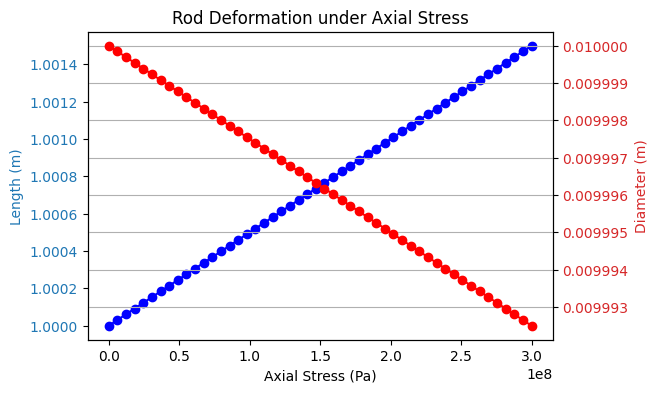

In [3]:
# Strain in directions x, y, z
eps_xx, eps_yy, eps_zz = 0, 0, 0

# lengths in direction x, y, z
Lx, Ly, Lz = 10, 10, 10

poisson_ratio = 0.5

E = 200e9          # Young's modulus (Pa), e.g., steel ~ 200 GPa
nu = 0.5           # Poisson's ratio for steel-like material
length_0 = 1.0     # initial length (meters)
diameter_0 = 0.01  # initial diameter (meters)

# Define a range of axial stresses (Pa) - from 0 to some maximum
max_stress = 300e6  # 300 MPa, for example
num_steps = 50
stresses = np.linspace(0, max_stress, num_steps)

# Prepare arrays to store results
lengths = np.zeros(num_steps)
diameters = np.zeros(num_steps)

# ----------------------------
# Simulation
# ----------------------------
for i, sigma_axial in enumerate(stresses):
    # 1) Axial strain ( Hooke's law: strain_axial = stress / E )
    epsilon_axial = sigma_axial / E

    # 2) Lateral strain ( Poisson effect: epsilon_trans = -nu * epsilon_axial )
    epsilon_trans = -nu * epsilon_axial

    # 3) Update rod’s length and diameter
    length = length_0 * (1 + epsilon_axial)
    diameter = diameter_0 * (1 + epsilon_trans)

    lengths[i] = length
    diameters[i] = diameter

# ----------------------------
# Print or Plot Results
# ----------------------------
# Example: print the final values
print(f"Final axial stress: {stresses[-1]:.2e} Pa")
print(f"Final axial strain: {epsilon_axial:.4e}")
print(f"Final rod length: {lengths[-1]:.4f} m")
print(f"Final rod diameter: {diameters[-1]:.6f} m")

# Plot the evolution of length and diameter
fig, ax1 = plt.subplots(figsize=(6,4))

ax1.set_xlabel("Axial Stress (Pa)")
ax1.set_ylabel("Length (m)", color='tab:blue')
ax1.plot(stresses, lengths, 'b-o', label="Length")
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()  # share the same x-axis
ax2.set_ylabel("Diameter (m)", color='tab:red')
ax2.plot(stresses, diameters, 'r-o', label="Diameter")
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title("Rod Deformation under Axial Stress")
plt.grid(True)
plt.show()


In [ ]:
# -----------------------------------------------------------
# 1) IMPORTS
# -----------------------------------------------------------
from dolfin import *
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# 2) MESH & FUNCTION SPACE
# -----------------------------------------------------------
# We'll simulate a unit cube [0,1]^3, subdivided into a grid.
# For a real case, refine the mesh further or use external meshing tools.
nx = ny = nz = 10  # number of divisions
mesh = UnitCubeMesh(nx, ny, nz)

# We use a VectorFunctionSpace (displacements in 3D).
V = VectorFunctionSpace(mesh, 'Lagrange', degree=1)

# -----------------------------------------------------------
# 3) BOUNDARY CONDITIONS
# -----------------------------------------------------------
# Let's fix (pin) the left face x=0 in all directions.
# We'll then apply a small displacement on the right face x=1
# to "stretch" the cube in the x-direction.

# Define the "left" boundary where x=0
def left_boundary(x, on_boundary):
    return on_boundary and near(x[0], 0.0)

# Define the "right" boundary where x=1
def right_boundary(x, on_boundary):
    return on_boundary and near(x[0], 1.0)

# On x=0 boundary, we fix displacement to zero in x,y,z
u0_left = Constant((0.0, 0.0, 0.0))
bc_left = DirichletBC(V, u0_left, left_boundary)

# On x=1 boundary, we apply a small positive displacement
# e.g., 0.01 in the x-direction (1% of the cube length).
# The y and z displacements remain 0, so the boundary
# can expand or contract in those directions due to Poisson effect.
u0_right = Constant((0.01, 0.0, 0.0))
bc_right = DirichletBC(V, u0_right, right_boundary, method="geometric")

bcs = [bc_left, bc_right]

# -----------------------------------------------------------
# 4) MATERIAL (LINEAR ELASTICITY)
# -----------------------------------------------------------
# We'll assume isotropic, linear elasticity with parameters:
# E   = Young's modulus
# nu  = Poisson's ratio
# lam, mu = Lame's constants (for the stress-strain relationship)

E  = 10.0     # Example: some arbitrary "units"
nu = 0.3      # Poisson's ratio typical for metals

# Lame's constants:
lmbda = E*nu / ((1.0 + nu) * (1.0 - 2.0*nu))
mu    = E / (2.0 * (1.0 + nu))

# Define strain and stress
def epsilon(u):
    # Symmetric gradient
    return 0.5*(grad(u) + grad(u).T)

def sigma(u):
    # Stress = lambda*tr(strain)*I + 2*mu*strain
    return lmbda*tr(epsilon(u))*Identity(len(u)) + 2.0*mu*epsilon(u)

# -----------------------------------------------------------
# 5) VARIATIONAL PROBLEM
# -----------------------------------------------------------
# We want to solve for displacement u that minimizes the elastic energy.
# The weak form is:  integral( sigma(u):epsilon(v) ) dV = 0, for all test v.

u  = Function(V)         # The unknown displacement
du = TrialFunction(V)
v  = TestFunction(V)

# a(du, v) = ∫ sigma(du):epsilon(v) dx
a = inner(sigma(du), epsilon(v))*dx

# No "body force" (like gravity) in this simple example, so the RHS is 0
L = Constant((0.0, 0.0, 0.0))  # zero forcing
rhs = dot(L, v)*dx

# Solve the linear system
solve(a == rhs, u, bcs)

# -----------------------------------------------------------
# 6) POST-PROCESSING / RESULTS
# -----------------------------------------------------------
# Now we can examine how the cube deforms.

# 6a) Let's compute min and max displacements in y and z to see the "shrinkage"
u_vals = u.vector().get_local().reshape((-1, 3))  # each row is [ux, uy, uz] at a node
uy_vals = u_vals[:,1]
uz_vals = u_vals[:,2]

print("---- RESULTS ----")
print(f"Max displacement in x-direction = {np.max(u_vals[:,0]):.5f}")
print(f"Min displacement in x-direction = {np.min(u_vals[:,0]):.5f}")
print(f"Max displacement in y-direction = {np.max(uy_vals):.5f}")
print(f"Min displacement in y-direction = {np.min(uy_vals):.5f}")
print(f"Max displacement in z-direction = {np.max(uz_vals):.5f}")
print(f"Min displacement in z-direction = {np.min(uz_vals):.5f}")

# 6b) Plot or visualize the displacement
#     1) Use Fenics plot
#     2) Save to file for Paraview or other

#  - Simple in-window plot:
#    (For a 3D domain, a pure matplotlib "plot" is less helpful than a specialized viewer,
#     but we show it for demonstration.)
import matplotlib.tri as tri
plot(u, title="Displacement field (magnitude)")
plt.show()

#  - To visualize in Paraview:
#    u.rename("displacement", "")
#    File("disp.pvd") << u
#
#    Then open disp.pvd in ParaView to see the 3D deformation.
